# Multi Linear Regression $\Delta\!$ MLat with Dipole Tilt and Vy

## Imports

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from scipy.stats import iqr

# Loading Dataset
Loading Onset file and created $\Delta\!$ MLat column

In [232]:
Onsets= pd.read_csv('../Paper_Figures/Mediated_Onsets.csv', parse_dates=['Date_NH'])
Onsets= Onsets[Onsets.flag==1][['Date_NH', 'Frey_MLT', 'Frey_MLAT', 'MLAT_SH']]
Onsets.loc[Onsets.Frey_MLT<12, 'Frey_MLT']+=24
Onsets['DMLAT']=Onsets['MLAT_SH']-Onsets['Frey_MLAT']

## Rounding Time
Rounding the NH image time to the nearest minute

In [233]:
diff= Onsets.Date_NH-Onsets.Date_NH.values.astype('datetime64[m]')
delta= np.zeros(diff.shape).astype('timedelta64[m]')
delta[diff.values>=np.timedelta64(30, 's')]=np.timedelta64(1, 'm')
Onsets['Date_UTC']=Onsets.Date_NH.values.astype('datetime64[m]').astype('datetime64[ns]')+delta

## Loading Omni
Load the omni data and set values to 'NaN' when the required number of data points in the window is not satisfied.

In [234]:
omni= pd.read_hdf('../omni_data.hdf5', key='omni_window_2h_20')
omni.loc[omni['points_BZ_GSM']<120*.9, ['BX_GSE_Mean','BY_GSM_Mean',
                                 'BZ_GSM_Mean','Clock_GSM_SEM',
                                 'Clock_GSM_Mean']]=np.nan
omni['Date_UTC']= omni.index.values
omni.index= list(range(len(omni)))

## Merging Omni and Onset dataframes using the time column

In [235]:
Onsets= Onsets.merge(omni, on='Date_UTC')

## Handling Outliers
We use 1.5 times the interquartile range over and under the upper and lower quartiles to define outliers and exclude them from feature importance

In [236]:
# Outliers
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim

## Removing Missing Solar Wind Data

In [237]:
Onsets= Onsets[Onsets.Vy.notnull()]

## Selecting Columns and Excluding Outliers

In [238]:
X1= Onsets[rm_out].Vy.values
X2= Onsets[rm_out].Dipole_Tilt.values
Y= Onsets[rm_out].DMLAT.values
X = np.column_stack((X1, X2))


/tmp/ipykernel_339130/4239892053.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X1= Onsets[rm_out].Vy.values
/tmp/ipykernel_339130/4239892053.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X2= Onsets[rm_out].Dipole_Tilt.values
/tmp/ipykernel_339130/4239892053.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Y= Onsets[rm_out].DMLAT.values


## Performing Multi Linear Fit

In [239]:
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

## Printing Fit Information

In [240]:
# Print Model Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Evaluate the Model
Y_pred = model.predict(X)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Intercept: -0.7388969304219944
Coefficients: [0.02565905 0.02478064]
Mean Squared Error: 2.235627536262789
R^2 Score: 0.26475251550242296


## Generating Contour Plotting Data

In [241]:
x1_lim= -100, 100
x2_lim= -40, 40
# Create a grid of values for X1 and X2 for plotting
x1_range = np.linspace(*x1_lim, 100)
x2_range = np.linspace(*x2_lim, 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
# Predict Y values for the grid
y_pred_grid = model.intercept_ + model.coef_[0] * x1_grid + model.coef_[1] * x2_grid

## Creating Figure and Plotting Results

/tmp/ipykernel_339130/907154486.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',
/tmp/ipykernel_339130/907154486.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',


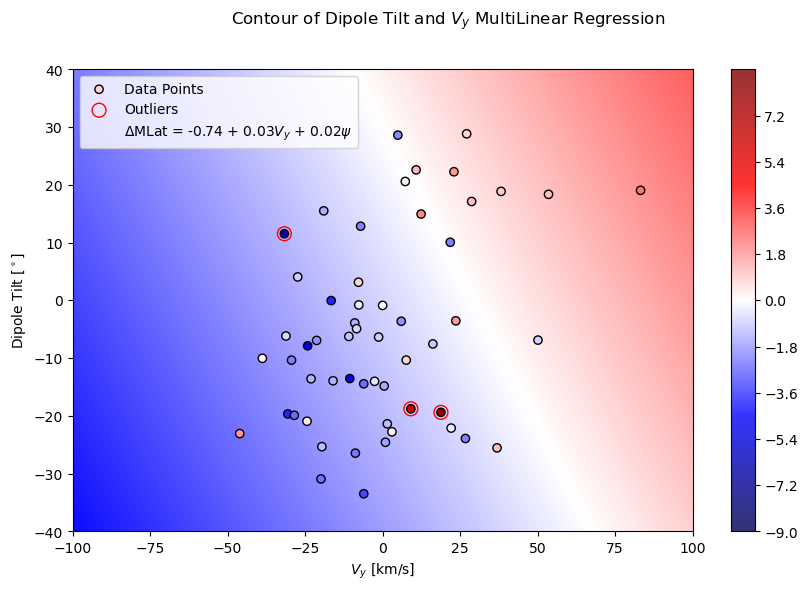

In [242]:
# Create Figure
fig= plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# Create Contour
contour = ax.contourf(x1_grid, x2_grid, y_pred_grid, alpha=0.8, cmap='seismic', vmin=-9, vmax=9,
                      levels= np.linspace(-9, 9, 10000))
cbar= fig.colorbar(contour)
# Scatter Data Points
ax.scatter(Onsets.Vy.values, Onsets.Dipole_Tilt.values, c=Onsets.DMLAT.values, cmap=contour.cmap, edgecolor='k', label='Data Points',
            vmin=contour.get_clim()[0], vmax=contour.get_clim()[1])  # Scatter plot of data
ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',
           facecolors='none', edgecolors='r', label='Outliers',
            s=100)  # Scatter plot of data
intercept = model.intercept_
coef_x1 = model.coef_[0]
coef_x2 = model.coef_[1]

# Format the equation as a LaTeX string
equation = (
    r"$\Delta$MLat = {:.2f} + {:.2f}$V_y$ + {:.2f}$\psi$"
    .format(intercept, coef_x1, coef_x2)
)
# Creeating Hidden Scatter to put equation in legend
ax.scatter(0, 0, color='white', label=equation, alpha=0)
# Set labels and limits
ax.set_xlabel('$V_y$ [km/s]')
ax.set_ylabel(r'Dipole Tilt [$^\circ$]')
ax.set_ylim(*x2_lim)
ax.set_xlim(*x1_lim)
fig.suptitle(r'Contour of Dipole Tilt and $V_y$ MultiLinear Regression')
ax.legend()

## Adding Extra Axes Information

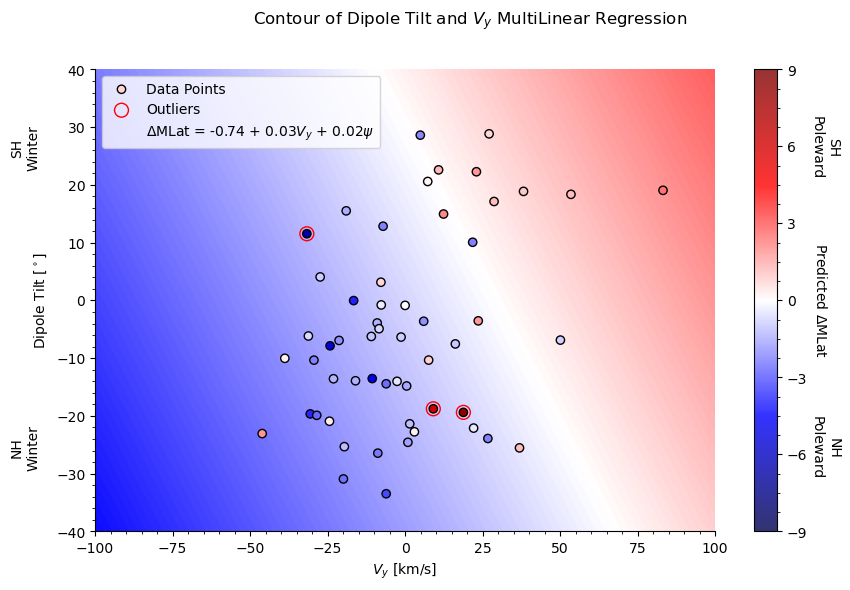

In [243]:
fig.text(.055, .25, 'NH\nWinter', rotation=90, va='center', ha='center')
fig.text(.055, .75, 'SH\nWinter', rotation=90, va='center', ha='center')

fig.text(.855, .25, 'NH\nPoleward', rotation=270, va='center', ha='center')
fig.text(.855, .75, 'SH\nPoleward', rotation=270, va='center', ha='center')
cbar.set_label(r'Predicted $\Delta$MLat', rotation=270, labelpad=15)
cbar.set_ticks(np.arange(-9, 10, 3))
ax.set_ylabel(r'Dipole Tilt [$^\circ$]')
# removing unneeded splines
for ax_ in (ax, cbar.ax):
    ax_.spines['top'].set_visible(False)
    ax_.minorticks_on()
ax.spines['right'].set_visible(False)
fig